In [65]:
import math
import torch
from torch import nn
from d2l import torch as d2l

In [66]:
def masked_softmax(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)

    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=1e-6)

        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [67]:
class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.W_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)

        scores = self.W_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)


class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)




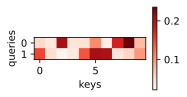

In [68]:
queries = torch.normal(0, 1, (2, 1, 20))
keys = torch.normal(0, 3, (2, 10, 2))
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)

valid_lens = torch.tensor([2, 6])

attention.eval()
attention(queries, keys, values, None)

d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)), xlabel='keys', ylabel='queries')

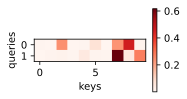

In [69]:
queries = torch.normal(0, 1, (2, 1, 2))
attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, None)

d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)), xlabel='keys', ylabel='queries')